# 1-bit CS

In this notebook we implement the renormalized fixed-point iteration (RFPI) and binary iterative hard thresholding (BIHT) algorithms for 1-bit compressive sensing. 

The following cell imports and runs our implementations defined in `onebit.py`. The `fit_sample()` function generates the synthetic signal and measurement matrix (with appropriate dimensions, given by the measurement values `Ms`, dimension `d`, sparsity `k`, and number of samples `n`), attempts to recover the signal using RFPI and BIHT, and reports the results. We also include a classical CS baseline, which uses lasso-lars to attempt to recover the signal. 

In [2]:
from onebit import fit_sample, fit_rfpi_variants, plot_cs_comparison, plot_rfpi_variant_comparison
import numpy as np

Ms = [50, 100, 200, 500, 1000, 2000, 3000]  

k = 16
d = 512
n = 10

threshold = k

Xh, Xh1, Xh2, mse_rfpi, mse_lars, mse_biht = fit_sample(n, d, k, Ms=Ms, threshold=threshold)


# Results

We compute the RMSE reconstruction accuracy in decibels and plot it against the number of measurements `M`.

rpfc avg sparsity: 15.9
lasso-lars avg sparsity: 16.0
biht avg sparsity: 16.0


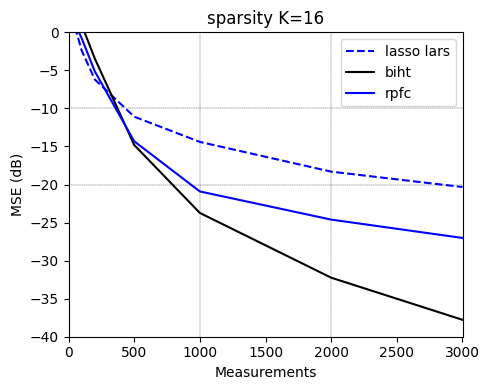

In [3]:
tol = 1e-3

print(f"rpfc avg sparsity: {np.mean(np.sum(np.abs(Xh) > tol, axis=0))}")
print(f"lasso-lars avg sparsity: {np.mean(np.sum(np.abs(Xh1) > tol, axis=0))}")
print(f"biht avg sparsity: {np.mean(np.sum(np.abs(Xh2) > tol, axis=0))}")

plot_cs_comparison(Ms, mse_lars, mse_rfpi, mse_biht, k)

# Results: RFPC

We plot the performance of a few variants of RFPC, where we modify the thresholding step. More details can be found in the report `1bit_report.pdf`. 

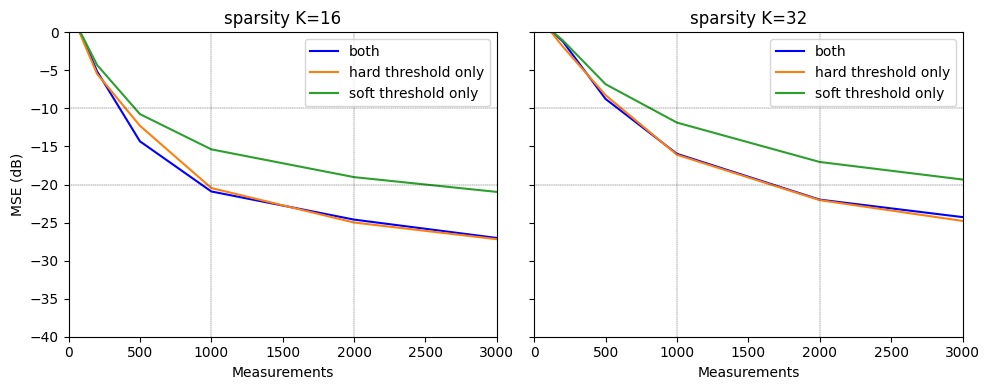

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, k_value in zip(axes, [16, 32]):
  mse_both, mse_hard, mse_soft = fit_rfpi_variants(n=n, d=d, k=k_value, Ms=Ms)
  plot_rfpi_variant_comparison(Ms, mse_both, mse_hard, mse_soft, k_value, ax=ax)

axes[1].set_ylabel('')
plt.tight_layout()
plt.show()